# AI-Assisted Bioinformatics — Solution
## Characterizing an unknown DNA sequence with Biopython & Matplotlib

**Course:** BIO116 · **Format:** guided Jupyter notebook · **Time:** ~90 minutes
**Audience:** students who know some Python and basic molecular biology
(DNA, codons, the central dogma) but are new to Biopython *and* to coding with
an AI assistant.

> ### What you are actually learning
> The biology here (GC content, reading frames, codon usage) is the *vehicle*.
> The real skill is a repeatable way of working with an AI coding assistant:
>
> ## 🧭 Decompose → 💬 Prompt → ✅ Verify
>
> 1. **Decompose** the problem into a small, well-defined step.
> 2. **Prompt** the assistant with enough context and constraints to solve
>    *just that step*.
> 3. **Verify** the result against biology you already trust — never ship code
>    you have not checked.
>
> An AI assistant is a fast, confident junior colleague who is sometimes wrong.
> Your job is not to type less; it is to *stay the expert who checks the work.*

---
## Section 0 · How to work with your AI assistant

You can use any assistant (Claude, Copilot, ChatGPT, a local model…). Throughout
this notebook you'll see three kinds of prompts:

| Badge | Meaning |
|-------|---------|
| 🧭 **Decompose** | The sub-problem, stated precisely. |
| 💬 **Prompt** | A starter prompt to paste into your assistant. Improve it! |
| ✅ **Verify** | The check you must run before trusting the output. |

### The five ways AI code goes wrong in bioinformatics
Watch for these — every one shows up in this notebook at least once:

1. **Hallucinated APIs** — methods like `seq.gc_content()` that *sound* real but
   don't exist in Biopython. *Fix:* run it; read the traceback; check the docs.
2. **Wrong genetic code** — using the standard table for a mitochondrial gene, or
   forgetting the stop codon. *Fix:* verify against a known protein.
3. **Off-by-one / frame errors** — coordinates that are 0- vs 1-based, or an ORF
   scan that misses a frame. *Fix:* test on a tiny sequence you can check by hand.
4. **Silent type confusion** — feeding a protein where DNA is expected, or a
   `str` where a `Seq` is expected. *Fix:* assert types and lengths.
5. **Stale library usage** — deprecated calls (e.g. `Bio.SeqUtils.GC`) or
   matplotlib patterns that warn. *Fix:* read the warning, don't ignore it.

### Rules of engagement
- **Never paste code you cannot explain.** If you can't read it, ask the
  assistant to explain it line by line — then verify *that* too.
- **One step at a time.** A prompt that asks for the whole pipeline gets a
  plausible-looking mess. Small prompts get checkable answers.
- **Biology is your oracle.** The genetic code, a known protein sequence, a base
  count that must sum to the sequence length — these don't lie. Code does.

---
## Section 1 · Set up and check your tools

First, a *verification* habit before we even start: confirm the libraries import
and print their versions. If this cell fails, fix your environment before going
on (`pip install -r requirements.txt`).

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import Bio
from Bio import Entrez, SeqIO
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction

print("Python     :", sys.version.split()[0])
print("Biopython  :", Bio.__version__)
print("matplotlib :", matplotlib.__version__)
print("\nTools ready ✅")

Python     : 3.11.15
Biopython  : 1.88
matplotlib : 3.11.2

Tools ready ✅


💬 **Prompt to try (warm-up):** paste this into your assistant and compare its
answer to what you just saw —

> *"In one sentence each, what are Biopython's `Bio.Seq.Seq`, `Bio.SeqIO`, and
> `Bio.Entrez` used for? I'm a student new to Biopython."*

✅ **Verify:** does its description of `SeqIO` match how we use it below (reading
and writing sequence files)? If it invents a method, note it — you've just seen
failure mode #1.

---
## Section 2 · Get a sequence from NCBI (with a safety net)

🧭 **Decompose.** We need a real coding sequence to analyze. The primary source
is **NCBI**, fetched live with `Bio.Entrez`. But networks fail — so we wrap the
download in a fallback to a bundled local sequence. *Robustness is part of the
job, and building the fallback is itself good practice.*

The configuration cell below is provided. Then **you** implement the one piece
that talks to NCBI: `_fetch_ncbi_cds`.

> ⚠️ Set `Entrez.email` to *your own* address — NCBI requires it and may block
> anonymous requests.

In [2]:
# --- Configuration (provided) --------------------------------------------
Entrez.email = "you@example.com"   # <-- put YOUR email here (NCBI requires it)
ACCESSION    = "NM_000518"          # human HBB (beta-globin) mRNA
USE_NCBI     = True                 # set False to force offline mode

# Resolve the data directory whether the notebook runs from repo root or notebooks/
DATA_DIR = next((p for p in (Path("data"), Path("../data")) if p.exists()), Path("../data"))
CACHE_DIR = DATA_DIR / "cache"
LOCAL_FASTA = DATA_DIR / "dna_sequence.fasta"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("Data directory:", DATA_DIR.resolve())

Data directory: /home/user/bio116/data


🧭 **Decompose.** Write *only* the NCBI call: given an accession, fetch its
coding sequence (CDS) as nucleotides and return a Biopython record.

💬 **Prompt to try:**
> *"Using Biopython's `Bio.Entrez` and `Bio.SeqIO`, write a function
> `_fetch_ncbi_cds(accession)` that downloads the coding sequence (CDS) as
> nucleotides for a nucleotide accession and returns a single SeqRecord. Use
> `db='nuccore'` and `rettype='fasta_cds_na'`. Close the handle. Raise a
> `ValueError` if nothing is returned."*

✅ **Verify** (in the wrapper + Section 2 checks below): the record's length is a
multiple of 3, and it starts with a start codon.

In [3]:
def _fetch_ncbi_cds(accession):
    "Download the CDS (nucleotides) for an accession and return a SeqRecord."
    handle = Entrez.efetch(db="nuccore", id=accession,
                           rettype="fasta_cds_na", retmode="text")
    records = list(SeqIO.parse(handle, "fasta"))
    handle.close()
    if not records:
        raise ValueError(f"No CDS returned for {accession!r}")
    return records[0]

The wrapper below is **provided**. Notice the pattern: *try the network, cache a
success, and on **any** failure fall back to the bundled sequence* so the rest of
the notebook always runs. This is why the whole exercise works even with no
internet — the fallback sequence is a real ~10.3 kb DNA fragment shipped in
`data/`.

In [4]:
def load_sequence(accession=ACCESSION, use_ncbi=USE_NCBI):
    "Return a SeqRecord from NCBI if possible, else from the bundled FASTA."
    if use_ncbi:
        try:
            rec = _fetch_ncbi_cds(accession)
            SeqIO.write(rec, CACHE_DIR / f"{accession}.fasta", "fasta")
            print(f"✅ Loaded {rec.id} from NCBI  ({len(rec.seq):,} bp)")
            return rec
        except Exception as exc:                      # network OR NotImplementedError
            print(f"⚠️  NCBI unavailable ({type(exc).__name__}: {exc}).")
            print("   Falling back to the bundled offline sequence.")
    rec = SeqIO.read(LOCAL_FASTA, "fasta")
    print(f"✅ Loaded {rec.id} from local file  ({len(rec.seq):,} bp)")
    return rec


record = load_sequence()
dna = record.seq
print("First 60 bases:", dna[:60])

⚠️  NCBI unavailable (URLError: <urlopen error Tunnel connection failed: 403 Forbidden>).
   Falling back to the bundled offline sequence.
✅ Loaded local_mystery_seq from local file  (10,309 bp)
First 60 bases: CCACCCCGAGCCTAGAGAAGGCTCCTAGCTTGGCTGGGCCTCATGGGGCCCTTGTCTGCT


✅ **Verify the record.** Before trusting *any* downstream result, sanity-check
what you actually got. Run the asserts below — if one fails, you learned
something about your data.

In [5]:
assert set(str(dna).upper()) <= set("ACGTN"), "Unexpected characters in DNA!"
print("Alphabet OK (only A/C/G/T/N).")
print(f"Length: {len(dna):,} bp   (multiple of 3? {len(dna) % 3 == 0})")
print(f"Starts with ATG? {str(dna[:3]).upper() == 'ATG'}")

Alphabet OK (only A/C/G/T/N).
Length: 10,309 bp   (multiple of 3? False)
Starts with ATG? False


---
## Section 3 · Base composition & GC content

🧭 **Decompose.** Compute the overall %GC — the fraction of bases that are G or C.
GC content is a basic fingerprint of a sequence (it correlates with gene density,
melting temperature, and organism).

💬 **Prompt to try:**
> *"I'm using Biopython. Write a function `gc_content(seq)` that takes a
> `Bio.Seq.Seq` or string of DNA and returns the percentage of G and C bases as
> a float rounded to 1 decimal. Implement the counting yourself — don't call a
> library GC function — and add a one-line docstring."*

✅ **Verify two ways:** (a) against Biopython's trusted `gc_fraction` as an
independent oracle, and (b) on a hand-checkable tiny input where you *know* the
answer.

In [6]:
def gc_content(seq):
    "Return the %GC of a DNA Seq/str as a float rounded to 1 decimal."
    s = str(seq).upper()
    gc = s.count("G") + s.count("C")
    return round(100 * gc / len(s), 1)

In [7]:
# ✅ Verify against a trusted library and a hand-checked case
overall = gc_content(dna)
library = round(gc_fraction(dna) * 100, 1)
print(f"gc_content(dna) = {overall}%   |   Biopython gc_fraction = {library}%")
assert abs(overall - library) <= 0.1, "Your GC% disagrees with Biopython!"

# 'GGCC' is 100% GC; 'ATATAT' is 0% GC -- you can check these by eye
assert gc_content("GGCC") == 100.0
assert gc_content("ATATAT") == 0.0
print("GC content verified ✅")

counts = Counter(str(dna).upper())
print("Base counts:", dict(counts))

gc_content(dna) = 65.9%   |   Biopython gc_fraction = 65.9%
GC content verified ✅
Base counts: {'C': 3526, 'A': 1644, 'G': 3270, 'T': 1869}


---
## Section 4 · The GC landscape (your first Matplotlib plot)

🧭 **Decompose.** A single %GC number hides *where* the GC-rich regions are. Slide
a window along the sequence and plot local %GC vs position. This is your first
matplotlib task — build the plot yourself.

💬 **Prompt to try (two steps — decompose!):**
> 1. *"Write `gc_windows(seq, window=100, step=20)` returning two lists:
>    the window-center positions and the %GC in each window, sliding by `step`."*
> 2. *"Now plot those with matplotlib: line plot, x = position (bp), y = %GC,
>    a dashed horizontal line at the genome-wide mean, axis labels, a title, and
>    `tight_layout()`. Use the object-oriented API (`fig, ax = plt.subplots()`)."*

✅ **Verify:** the number of windows equals `len(range(0, len(seq)-window+1, step))`,
and the *mean of the window values* is close to the overall %GC from Section 3.

In [8]:
def gc_windows(seq, window=100, step=20):
    "Return (centers, gc_values) for a sliding GC window along seq."
    s = str(seq).upper()
    centers, values = [], []
    for i in range(0, len(s) - window + 1, step):
        sub = s[i:i + window]
        values.append(100 * (sub.count("G") + sub.count("C")) / window)
        centers.append(i + window // 2)
    return centers, values

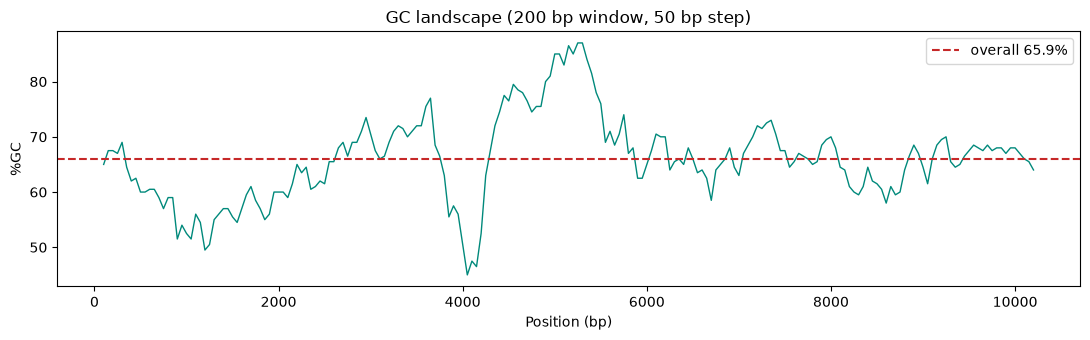

In [9]:
WINDOW, STEP = 200, 50
centers, values = gc_windows(dna, window=WINDOW, step=STEP)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(centers, values, lw=1, color="#00897b")
ax.axhline(gc_content(dna), ls="--", color="#c62828",
           label=f"overall {gc_content(dna)}%")
ax.set_xlabel("Position (bp)")
ax.set_ylabel("%GC")
ax.set_title(f"GC landscape ({WINDOW} bp window, {STEP} bp step)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

In [10]:
# ✅ Verify the windows
expected = len(range(0, len(dna) - WINDOW + 1, STEP))
print(f"windows: {len(values)}  (expected {expected})")
assert len(values) == expected
mean_window_gc = round(sum(values) / len(values), 1)
print(f"mean window %GC = {mean_window_gc}  vs overall {gc_content(dna)}")
assert abs(mean_window_gc - gc_content(dna)) < 3, "Window mean far from overall GC?"
print("GC landscape verified ✅")

windows: 203  (expected 203)
mean window %GC = 65.9  vs overall 65.9
GC landscape verified ✅


---
## Section 5 · Find the genes: a six-frame ORF search

🧭 **Decompose.** A protein-coding stretch is an **open reading frame (ORF)**: it
runs from a start codon (`ATG`) to the next in-frame stop (`TAA`, `TAG`, `TGA`).
A gene can sit on either strand and in any of 3 frames, so we scan **six frames**
(3 forward + 3 on the reverse complement) and keep the longest ORFs.

This is where failure mode #3 (frame / off-by-one bugs) bites. **Test on a tiny
sequence first**, where you can count the answer by hand.

💬 **Prompt to try:**
> *"Write `find_orfs(seq, min_aa=100)` for a Biopython `Seq`. Scan all six reading
> frames (forward and reverse-complement, frames 0/1/2). An ORF starts at `ATG`
> and ends at the next in-frame stop codon (TAA/TAG/TGA). Return a list of dicts
> with keys strand (+1/-1), frame, start, end, aa_len, and the ORF's nucleotide
> `Seq`, keeping only ORFs of at least `min_aa` amino acids, sorted longest first.
> Explain how you avoid double-counting nested ATGs."*

✅ **Verify:** translate the longest ORF and confirm it *starts with `M`*, *ends
with a single `*`*, and has *no internal stop codons* — the signature of a real
coding sequence. Also run the tiny hand-checkable test.

In [11]:
def find_orfs(seq, min_aa=100):
    "Six-frame ORF finder. Returns a list of dicts sorted by aa_len desc."
    stops = {"TAA", "TAG", "TGA"}
    n = len(seq)
    orfs = []
    for strand, nuc in [(+1, seq), (-1, seq.reverse_complement())]:
        s = str(nuc).upper()
        for frame in range(3):
            i = frame
            while i < n - 2:
                if s[i:i + 3] == "ATG":
                    j = i
                    while j < n - 2:
                        if s[j:j + 3] in stops:
                            aa_len = (j - i) // 3
                            if aa_len >= min_aa:
                                orfs.append({
                                    "strand": strand, "frame": frame,
                                    "start": i, "end": j + 3,
                                    "aa_len": aa_len, "nuc": nuc[i:j + 3],
                                })
                            break
                        j += 3
                    i = j + 3          # jump past this ORF: no nested double-count
                else:
                    i += 3
    return sorted(orfs, key=lambda o: o["aa_len"], reverse=True)

In [12]:
# ✅ Verify: a tiny hand-checkable case, then the real data
tiny = Seq("ATGAAATAG")          # ATG AAA TAG -> M K * : 2 amino acids
hits = find_orfs(tiny, min_aa=1)
assert hits and hits[0]["aa_len"] == 2, "Tiny ORF test failed -- check your frames!"

orfs = find_orfs(dna, min_aa=100)
print(f"ORFs >= 100 aa: {len(orfs)}")
best = orfs[0]
protein = best["nuc"].translate()
print(f"longest ORF: {best['aa_len']} aa, strand {best['strand']:+d}, "
      f"frame {best['frame']}, {best['start']}-{best['end']}")
print("protein head:", protein[:40])
assert str(protein).startswith("M"), "ORF should start with Met"
assert str(protein).endswith("*"), "ORF should end with a stop"
assert str(protein)[:-1].count("*") == 0, "No internal stops allowed in an ORF"
print("ORF verified ✅  (starts M, ends *, no internal stops)")

ORFs >= 100 aa: 13
longest ORF: 330 aa, strand +1, frame 1, 9286-10279
protein head: MPLAGQGCRDTPPFVQGIPHSPFSPANTTLALLSRGRHTP
ORF verified ✅  (starts M, ends *, no internal stops)


---
## Section 6 · Codon usage of the main ORF

🧭 **Decompose.** Different codons encode the same amino acid, and organisms
*prefer* some over others (codon bias). Count the 64 codons in the ORF we found
and plot their frequencies.

💬 **Prompt to try:**
> *"Write `codon_counts(cds)` returning a `collections.Counter` of the 3-letter
> codons in a coding sequence whose length is a multiple of 3."*

✅ **Verify:** the counts sum to `len(cds) // 3`, and every codon key translates
(via `Seq(codon).translate()`) to the amino acid you'd expect from the genetic
code. The plotting cell is provided — read it to learn the matplotlib idiom.

In [13]:
def codon_counts(cds):
    "Return a Counter of 3-letter codons in a length-multiple-of-3 sequence."
    s = str(cds).upper()
    return Counter(s[i:i + 3] for i in range(0, len(s) - 2, 3))

In [14]:
# ✅ Verify codon counts
cds = best["nuc"]
ccounts = codon_counts(cds)
assert sum(ccounts.values()) == len(cds) // 3, "Codon counts must sum to len/3"
# Spot-check the genetic code: every ATG is Met, every TGG is Trp
assert Seq("ATG").translate() == "M" and Seq("TGG").translate() == "W"
print(f"{sum(ccounts.values())} codons counted, {len(ccounts)} distinct ✅")

331 codons counted, 47 distinct ✅


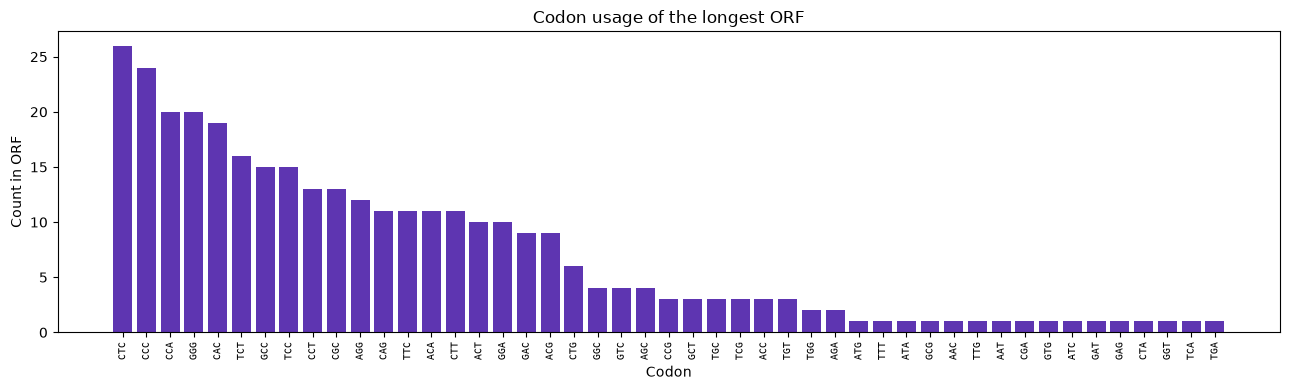

In [15]:
# Provided plot: codons sorted by frequency (read this to learn the idiom)
items = ccounts.most_common()
labels = [c for c, _ in items]
heights = [n for _, n in items]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(labels)), heights, color="#5e35b1")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7, family="monospace")
ax.set_xlabel("Codon")
ax.set_ylabel("Count in ORF")
ax.set_title("Codon usage of the longest ORF")
fig.tight_layout()
plt.show()

---
## Section 7 · Amino-acid composition

🧭 **Decompose.** Translate the ORF and count amino acids. Composition hints at a
protein's character (e.g. membrane proteins are hydrophobic-rich).

💬 **Prompt to try:**
> *"Write `aa_composition(protein)` returning a `Counter` of amino acids in a
> `Seq` protein, excluding the stop symbol `*`."*

✅ **Verify:** the counts sum to the protein length *without* the trailing stop.

In [16]:
def aa_composition(protein):
    "Return a Counter of amino acids in a protein Seq, excluding '*'."
    return Counter(str(protein).replace("*", ""))

330 residues across 18 amino-acid types ✅


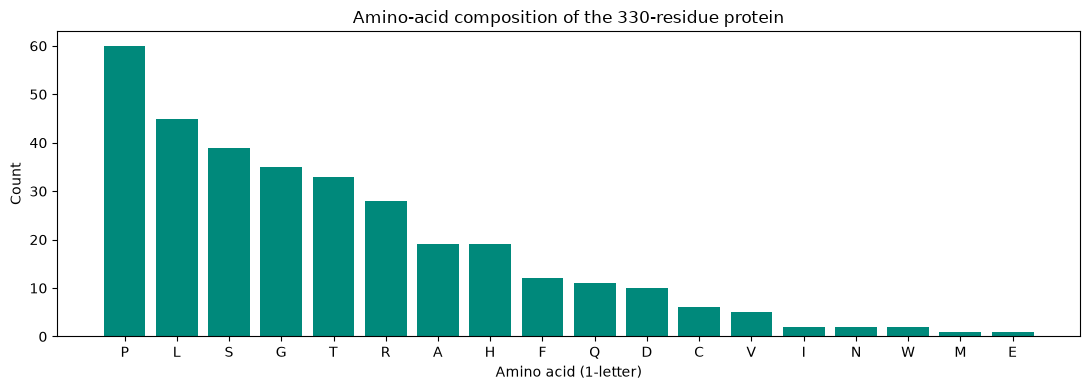

In [17]:
# ✅ Verify then plot amino-acid composition
aa = aa_composition(protein)
assert sum(aa.values()) == len(str(protein).replace("*", "")), "AA counts mismatch"
print(f"{sum(aa.values())} residues across {len(aa)} amino-acid types ✅")

order = sorted(aa, key=aa.get, reverse=True)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(order, [aa[a] for a in order], color="#00897b")
ax.set_xlabel("Amino acid (1-letter)")
ax.set_ylabel("Count")
ax.set_title(f"Amino-acid composition of the {len(str(protein))-1}-residue protein")
fig.tight_layout()
plt.show()

---
## Section 8 · Challenge — drive it yourself

Now *you* lead, using the same Decompose → Prompt → Verify loop. Pick **one** (or
more) and add cells below. There are no scaffolds here on purpose.

1. **Compare two genes.** Load a second accession (e.g. `NM_000559` for human
   HBG1) and plot the two GC landscapes on shared axes. Which is more GC-rich?
2. **Restriction map.** Use `Bio.Restriction` to find `EcoRI` / `BamHI` sites in
   your sequence and mark them on the GC-landscape plot.
3. **Reverse-complement check.** Show that translating the reverse complement of
   your ORF does **not** give a clean protein — evidence the strand matters.
4. **Codon bias, quantified.** Compute RSCU (relative synonymous codon usage) for
   one amino acid family (e.g. Leucine's 6 codons) and bar-plot it.

> For each: write down your prompt, then **write down the verification** you used
> before believing the answer. The verification is the graded part.

**Worked example for challenge #3 (reverse-complement sanity check):**

In [18]:
rc_protein = best["nuc"].reverse_complement().translate()
internal_stops = str(rc_protein)[:-1].count("*")
print("RC translation head:", rc_protein[:40])
print(f"internal stop codons on the wrong strand: {internal_stops}")
assert internal_stops > 0, "Reverse strand should be riddled with stops"
print("Confirmed: the reverse strand is NOT a clean ORF ✅  (strand matters!)")

RC translation head: SPASDAPSRQ*PARCGRSQGGTRQP*RAPGLGKSIDGEAG
internal stop codons on the wrong strand: 2
Confirmed: the reverse strand is NOT a clean ORF ✅  (strand matters!)


---
## Section 9 · Reflect & hand in

**What to submit:** this notebook, run top to bottom (`Kernel → Restart & Run
All`), with every ✅ verify cell passing, plus your Section 8 challenge.

**Reflection (write 3–5 sentences in the next cell):**
1. Where did your AI assistant produce code that was *wrong or outdated*? How did
   your verification catch it?
2. Which verification gave you the most confidence, and why?
3. Rewrite one prompt from today that you'd now write differently. What changed?

> **The takeaway.** AI made you *faster*, but the biology-based checks made you
> *right*. In real bioinformatics, an unverified plot is worse than no plot — it
> looks authoritative while being wrong. Decompose → Prompt → **Verify.**

_Your reflection here (double-click to edit):_

1. …
2. …
3. …